In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [2]:
#Multiple mice
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

animal = 'astroM10'

fc_traces = collection_fc.animals[animal].accepted_traces.to_numpy()

In [3]:
fc_traces

array([[ 4.37204052e-03,  4.59668786e-03,  3.20258957e-03, ...,
         8.39634541e-04,  3.78661941e-03,  3.69150633e-03],
       [ 2.89504351e-03,  2.91366034e-03,  1.42269593e-03, ...,
        -1.34701581e-04,  3.95752146e-03,  2.84616473e-03],
       [ 3.29039415e-03,  2.95152254e-03,  2.01654834e-03, ...,
         2.76972466e-04,  5.04664527e-03,  3.55276928e-03],
       ...,
       [ 1.16723255e-03,  6.66874430e-04,  6.65055231e-04, ...,
        -1.05155221e-06,  7.97610882e-04,  5.51062766e-04],
       [ 1.82566554e-03,  5.22558055e-04,  2.17747071e-03, ...,
        -2.61067779e-04,  1.20391250e-03,  1.09187928e-03],
       [ 1.95609044e-03,  2.93149735e-04,  1.63714173e-03, ...,
         7.14885620e-04,  1.52218469e-03,  1.18209558e-03]])

In [4]:
fc_df = fc_traces[:3303,:].T
fc_df

array([[ 0.00437204,  0.00289504,  0.00329039, ...,  0.0024173 ,
         0.00259586,  0.00288221],
       [ 0.00459669,  0.00291366,  0.00295152, ...,  0.00108361,
         0.00027802,  0.00125354],
       [ 0.00320259,  0.0014227 ,  0.00201655, ...,  0.00209607,
         0.00234485,  0.00396372],
       ...,
       [ 0.00083963, -0.0001347 ,  0.00027697, ...,  0.00092158,
         0.0024502 ,  0.0009783 ],
       [ 0.00378662,  0.00395752,  0.00504665, ...,  0.00255701,
         0.00240149,  0.00305783],
       [ 0.00369151,  0.00284616,  0.00355277, ...,  0.00148313,
         0.00140018,  0.00085255]])

In [5]:
across_eta_, time = onep.eta_individual_cells(
    data=fc_df,
    timestamps=collection_fc.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300], ],  #detected onsets
    window=28
)

In [6]:
mu_fc = pd.read_csv("/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/rui_modeling_plots_csv/astrocyte_shot_Gaussian_noise3_all.csv")
mu_fc

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal
0,1,0.0,0.0,2.6,0.5,0.5,0.512348,2.675,2.6,2.9,2.0,3.2,1,F3.
1,10,0.0,0.0,2.3,0.8,0.6,0.493288,2.350,2.3,2.3,1.8,3.0,10,F3.
2,100,0.0,0.0,13.0,8.1,0.8,2.459505,5.325,7.1,4.2,7.6,2.4,100,F3.
3,1000,0.1,0.0,3.2,0.8,0.3,0.287228,3.175,3.1,3.0,3.0,3.6,1000,F9.
4,1001,0.1,0.0,3.7,1.3,0.2,0.330404,3.625,3.2,3.7,3.6,4.0,1001,F9.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3080,995,0.1,0.0,4.1,0.9,1.5,1.797220,3.850,2.4,2.4,4.5,6.1,995,F9.
3081,996,0.1,0.0,3.2,1.1,0.2,0.000000,3.200,3.2,3.2,3.2,3.2,996,F9.
3082,997,0.1,0.0,3.2,0.9,0.5,0.408248,3.200,3.3,2.6,3.4,3.5,997,F9.
3083,998,0.2,0.0,5.6,2.2,0.2,0.320156,5.675,5.8,5.2,5.9,5.8,998,F9.


In [7]:
animal_to_filter = ['M10']

# Use .isin() to filter the DataFrame
mu_fc_animal = mu_fc[mu_fc['animal'].isin(animal_to_filter)]
mu_fc_animal

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal
2125,2912,0.2,0.0,3.1,0.8,0.5,0.579511,2.975,2.2,3.0,3.1,3.6,2912,M10
2126,2913,0.0,0.0,3.4,1.1,1.1,0.994987,3.450,2.3,3.6,3.2,4.7,2913,M10
2127,2914,0.0,0.0,2.9,0.9,0.6,0.704154,3.075,2.5,2.9,2.8,4.1,2914,M10
2128,2915,0.1,0.0,3.5,1.0,0.5,0.516398,3.500,2.9,4.1,3.3,3.7,2915,M10
2129,2916,0.1,0.0,5.6,1.5,4.9,2.921757,4.150,2.2,2.9,3.0,8.5,2916,M10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2314,3082,0.0,0.0,2.3,0.8,0.2,0.244949,2.300,2.0,2.3,2.3,2.6,3082,M10
2315,3083,0.0,0.0,3.1,0.9,0.5,0.537742,3.025,2.4,2.9,3.1,3.7,3083,M10
2316,3084,0.0,0.0,2.5,0.8,0.5,0.535413,2.600,2.0,2.6,2.5,3.3,3084,M10
2317,3085,0.0,0.0,2.8,0.9,0.5,0.478714,2.825,2.4,2.8,2.6,3.5,3085,M10


In [8]:
mu_fc_animal = mu_fc_animal.iloc[:, :]
mu_fc_animal['across_eta_fc'] = across_eta_.tolist()

In [9]:
sorted = mu_fc_animal.sort_values(by='pred_mu')
sorted

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,across_eta_fc
2293,3063,0.0,0.0,1.3,0.7,1.2,1.099621,1.625,1.9,2.3,2.3,0.0,3063,M10,"[0.0017322474882721143, 0.0019980061832679907,..."
2252,3026,0.0,0.0,1.6,0.9,4.9,1.178983,1.750,2.1,2.5,2.4,0.0,3026,M10,"[0.0015567151071142677, 0.0013144848371916358,..."
2203,2983,0.0,0.0,1.8,0.6,0.4,0.411299,1.875,1.4,1.8,1.9,2.4,2983,M10,"[0.0028018876891753317, 0.0028638604897111854,..."
2218,2997,0.0,0.0,1.8,0.4,0.9,0.556028,1.825,1.3,1.8,1.6,2.6,2997,M10,"[0.00253576337871982, 0.00353845046963766, 0.0..."
2215,2994,0.0,0.0,1.8,0.5,0.4,0.341565,1.850,1.5,1.7,1.9,2.3,2994,M10,"[0.0035111367347653265, 0.004196544990406994, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2183,2965,0.0,0.0,6.0,0.8,2.2,1.915507,5.025,3.0,5.0,4.5,7.6,2965,M10,"[0.0026301906192047753, 0.0025339302496446836,..."
2194,2975,0.0,0.0,6.0,1.0,1.0,0.892095,6.175,5.1,5.9,6.5,7.2,2975,M10,"[0.003064321398213915, 0.0019525373676646915, ..."
2146,2931,0.0,0.0,6.1,1.6,12.4,3.057777,5.350,2.0,5.3,4.7,9.4,2931,M10,"[0.0022165227909101996, 0.0018482022431833224,..."
2162,2946,0.1,0.0,6.1,0.8,5.3,5.236093,5.050,2.2,2.6,2.5,12.9,2946,M10,"[0.002685991249451888, 0.0019636416117056014, ..."


In [10]:
across_eta_fc_sorted = sorted['across_eta_fc'].tolist()

In [11]:
across_eta_fc_sorted

[[0.0017322474882721143,
  0.0019980061832679907,
  0.002148373797625511,
  0.002384590376042871,
  0.0017773625419247826,
  0.0017684052105291313,
  0.001973084182458238,
  0.0011773617480923494,
  0.001042166406451397,
  0.0011786478717409766,
  0.001988242049138592,
  0.0022692736522335203,
  0.0019521975538312301,
  0.0024412833687406325,
  0.003396540677802526,
  0.00323162062784745,
  0.0015712723190438166,
  0.001793489249551014,
  0.0013359358167884354,
  0.0021332534147346905,
  0.0030763477843902534,
  0.002607520143599336,
  0.0021277891181090847,
  0.0027026643846976748,
  0.003291818861764973,
  0.003023167925274439,
  0.002398687710003363,
  0.002575608228674863,
  0.0018847570096628356,
  0.00111509409462333,
  0.0015333270641315054,
  0.0023440230109393464,
  0.0026747084553473935,
  0.0021510525675729813,
  0.003234807487692307,
  0.002070677481856544,
  0.002012805795172129,
  0.002485483078874397,
  0.0024308099310722557,
  0.0021365612676976214,
  0.0026640271447542

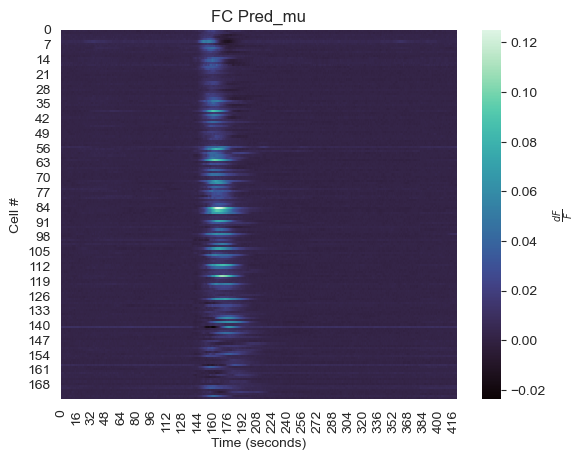

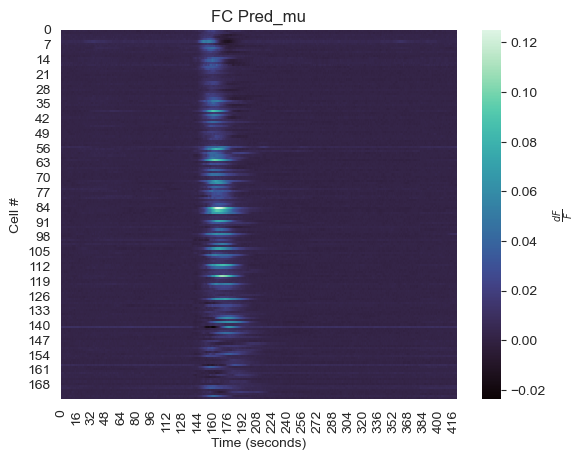

In [13]:
fig, ax = plt.subplots()
sns.heatmap(across_eta_fc_sorted, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
# ax.set_xticks(np.linspace(0, len(across_eta.T), 5), time)
ax.set_title('FC Pred_mu')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
plt.show()